In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import pandas as pd

from lib.loading import extract_all_set_collection
from lib.build_pairs import build_pairs  
from lib.calculate_micro_macro_samples import calculate_micro_macro_samples
from lib.calculate_samples_with_std import calculate_samples_with_std
from lib.plot_micro_macro_samples import plot_micro_macro_samples
from lib.plot_all_micro_macro_samples import plot_all_micro_macro_samples
from lib.plot_runs_with_std import plot_runs_with_std

In [2]:
runs = extract_all_set_collection("../data/waze_results_10_runs")
print(f"{len(runs)} Runs loaded")

10 Runs loaded


In [3]:
pair_keys = [
    ("permissions_set_1", "inferred_permissions"),
    ("permissions_set_2", "inferred_permissions"),
    ("apk_permissions", "inferred_permissions"),
    ("apk_permissions", "permissions_set_1"),
    ("apk_permissions", "permissions_set_2"),
]

rows = []
for truth_key, pred_key in pair_keys:
    comps = build_pairs(runs, truth_key, pred_key)
    rows.append(calculate_micro_macro_samples(comps, truth_key, pred_key))

results_df = pd.DataFrame(rows)
results_df

,compare,label_gt_pred,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,precision_samples,recall_samples,f1_samples
0,set1_pipeline,Set 1 / Pipeline,0.38000,0.950000,0.542857,0.285714,0.271429,0.277778,0.380505,0.950000,0.542930
1,set2_pipeline,Set 2 / Pipeline,0.79000,0.343478,0.478788,0.370370,0.292593,0.309473,0.790303,0.343478,0.478420
2,apk_pipeline,APK / Pipeline,0.81000,0.311538,0.450000,0.379310,0.279310,0.299624,0.809394,0.311538,0.449528
3,apk_set1,APK / Set 1,1.00000,0.153846,0.266667,0.153846,0.153846,0.153846,1.000000,0.153846,0.266667
4,apk_set2,APK / Set 2,0.73913,0.653846,0.693878,0.531250,0.531250,0.531250,0.739130,0.653846,0.693878


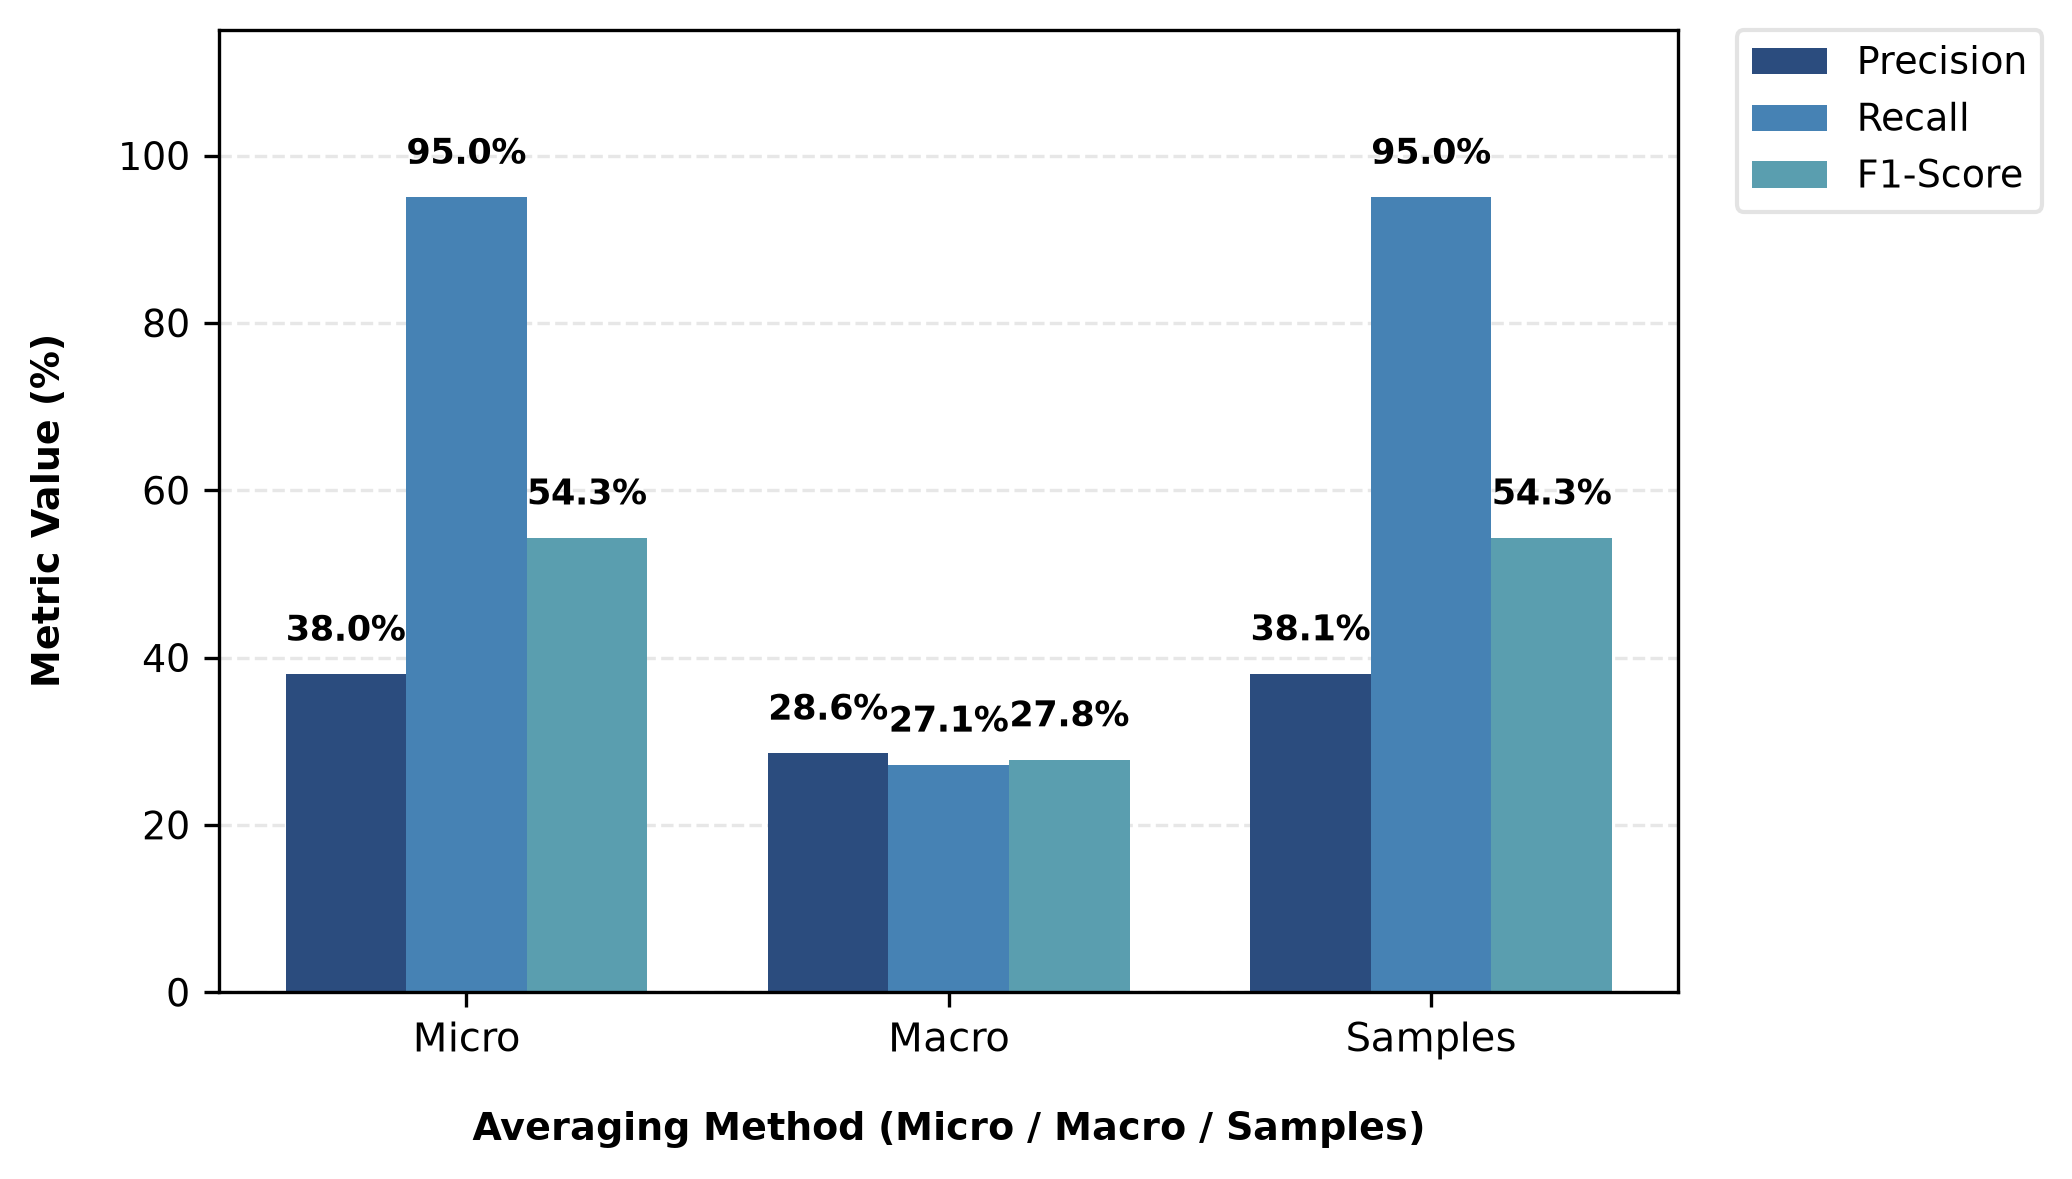

In [4]:
plot_micro_macro_samples(rows, "set1_pipeline", "../figures/figures_waze_10_runs")

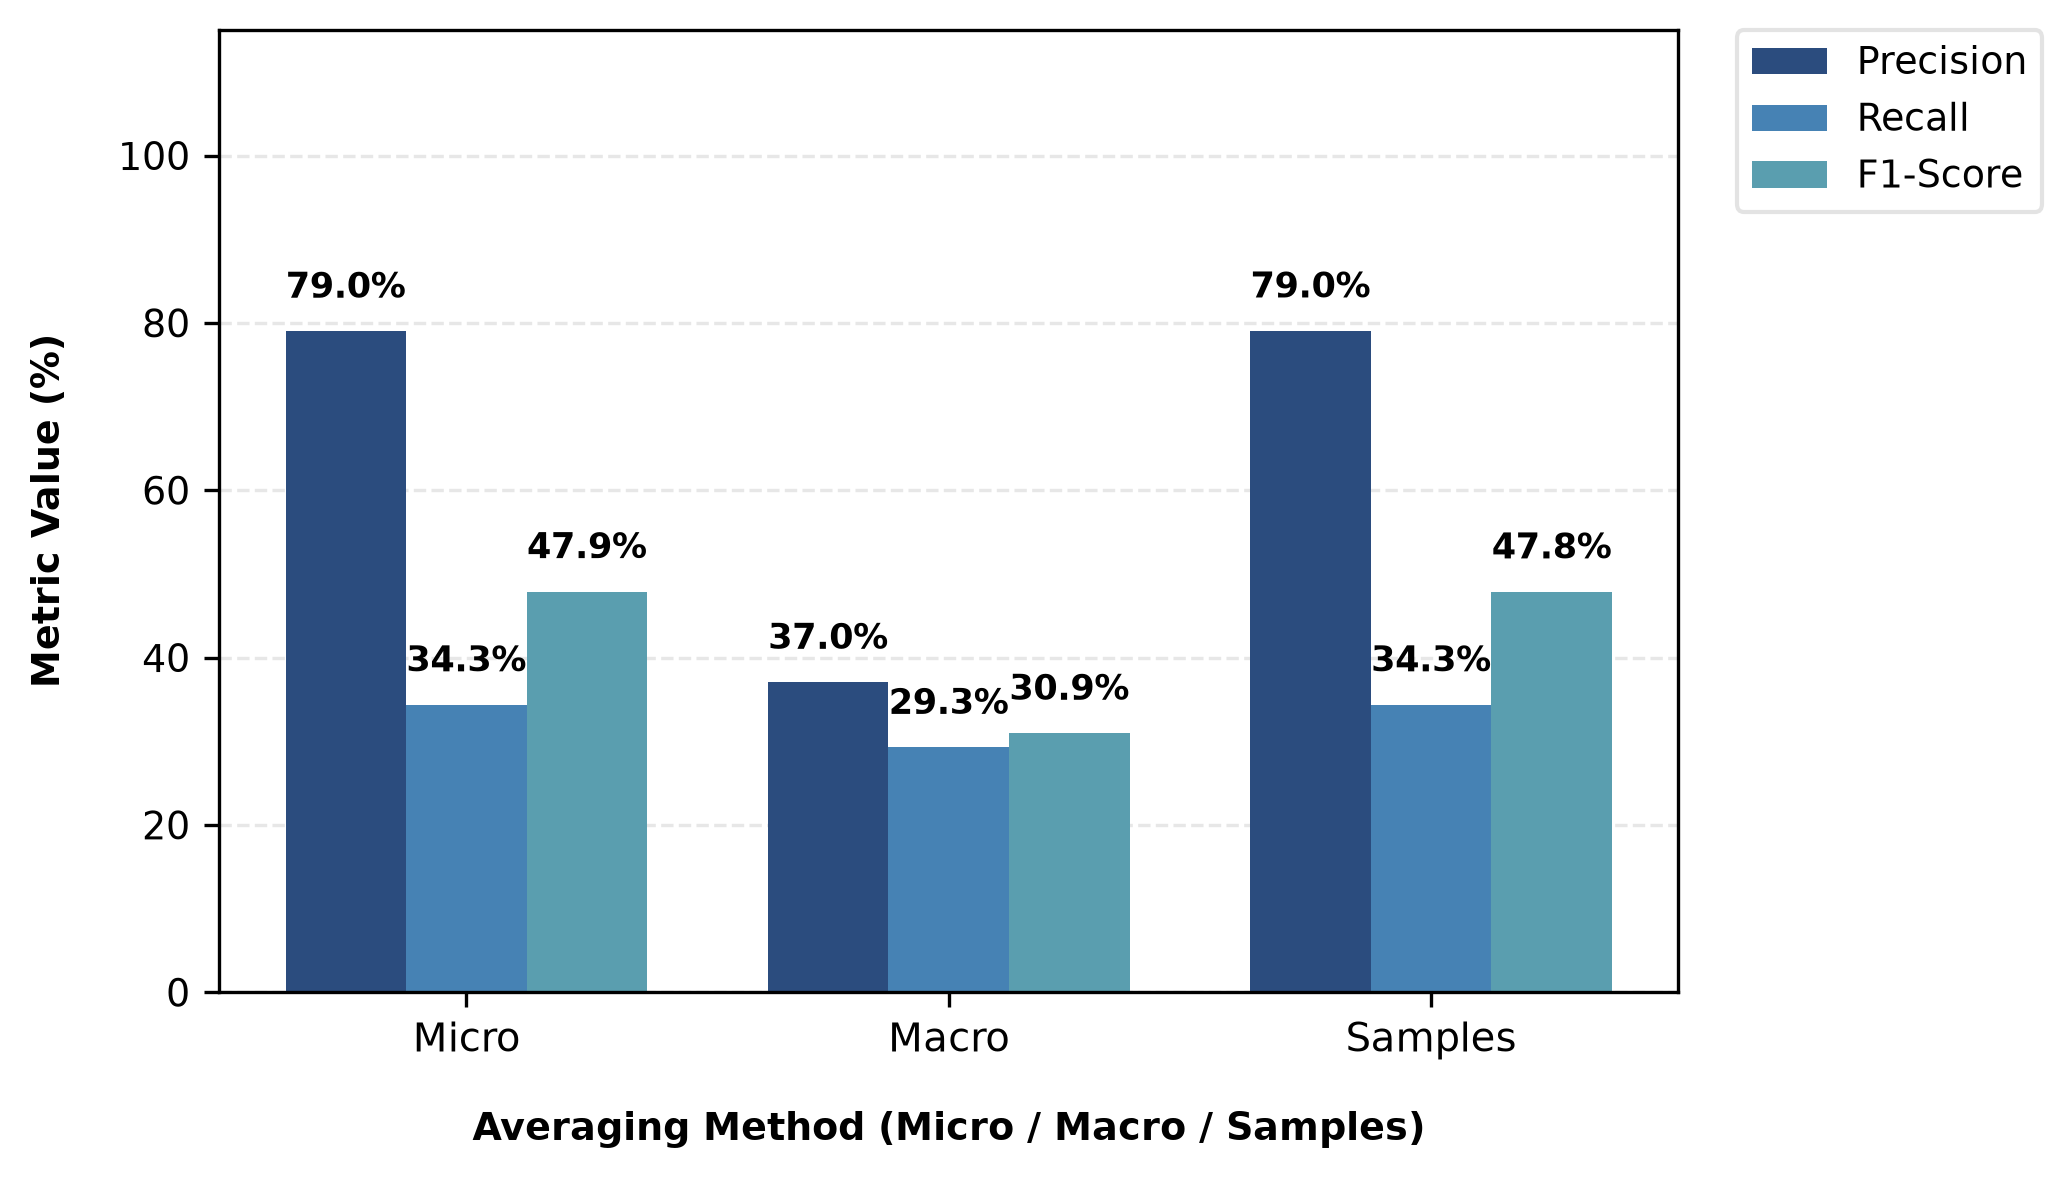

In [5]:
plot_micro_macro_samples(rows, "set2_pipeline", "../figures/figures_waze_10_runs")

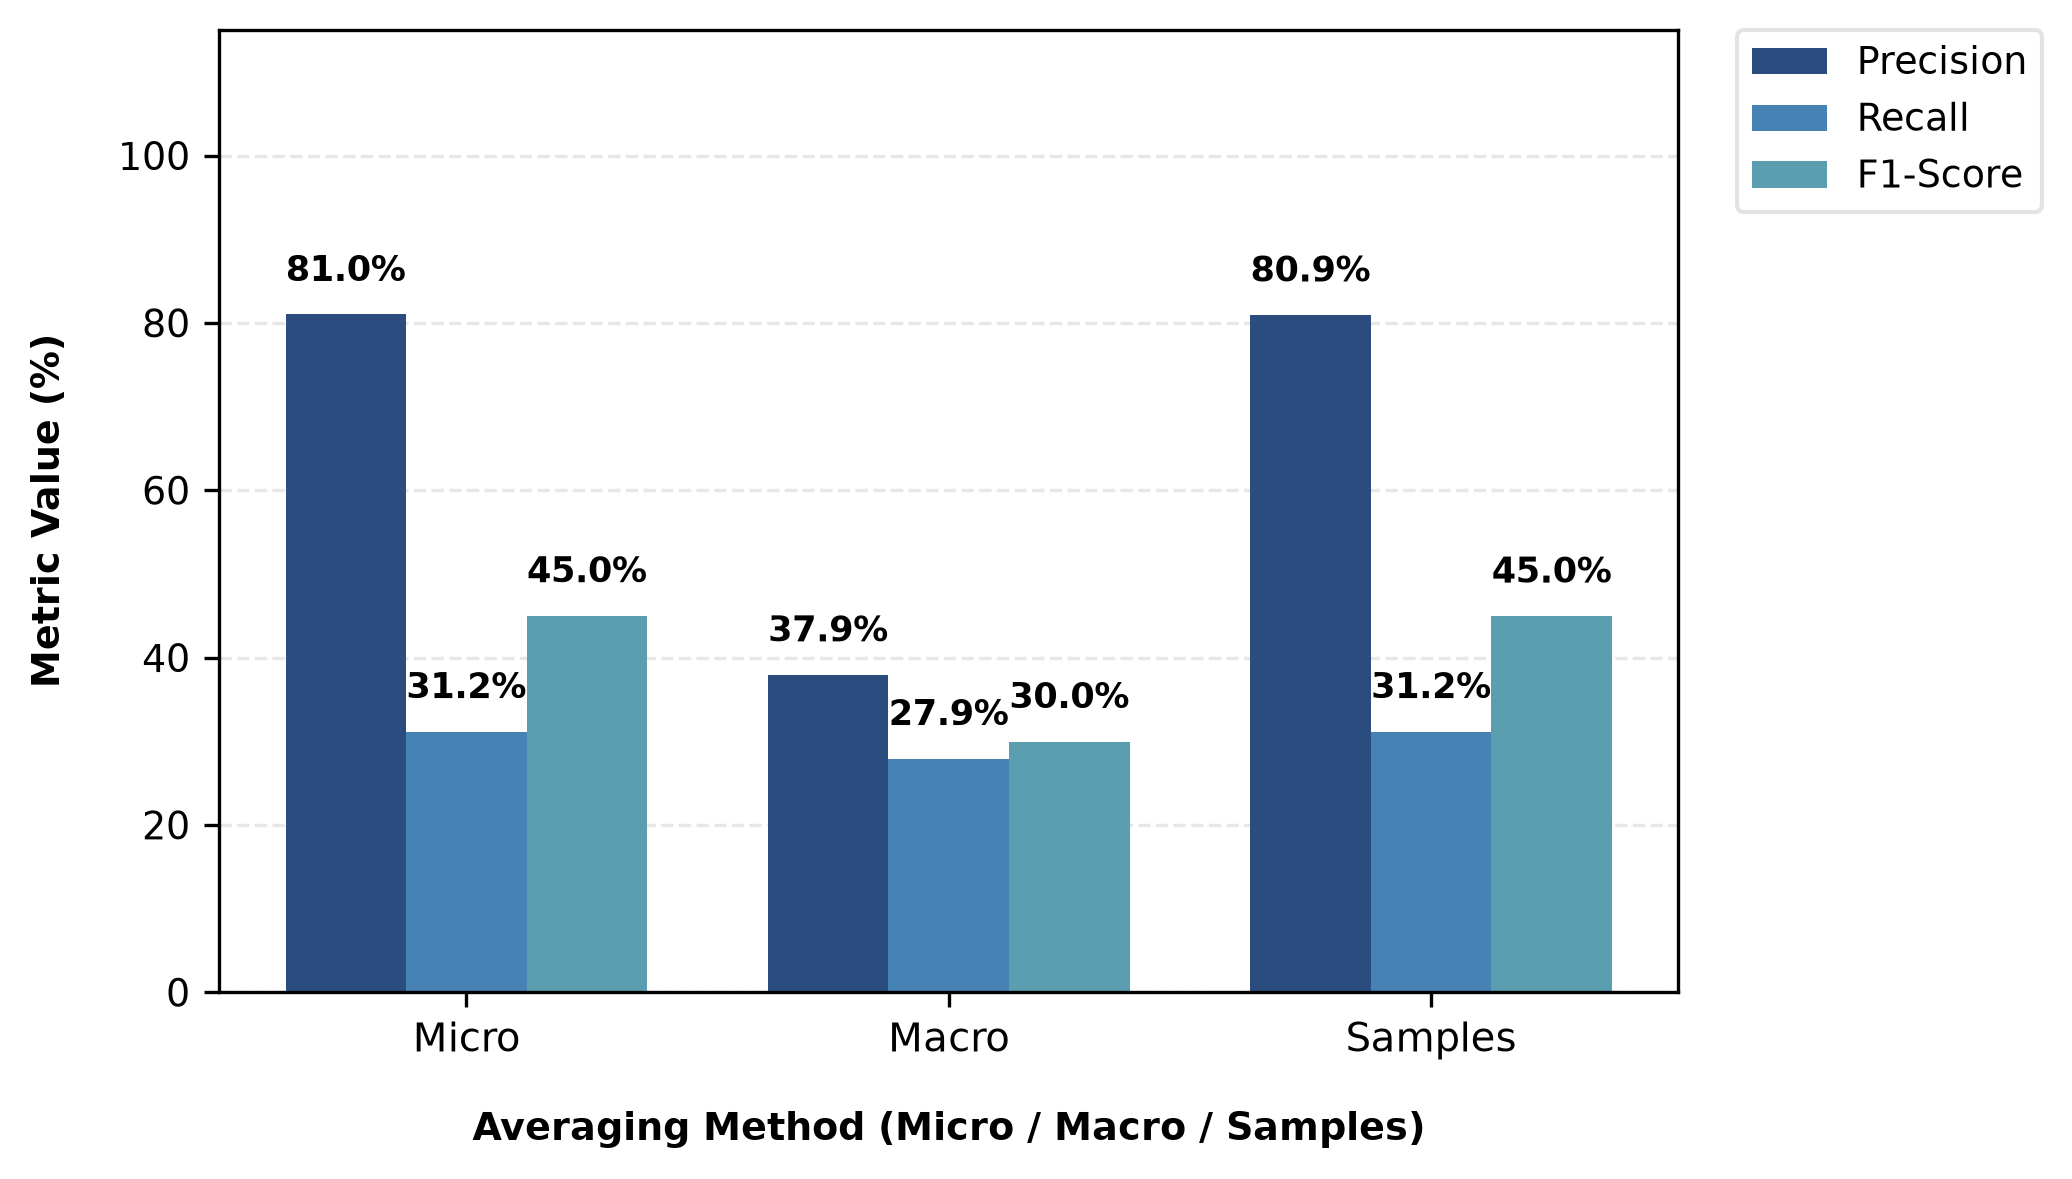

In [6]:
plot_micro_macro_samples(rows, "apk_pipeline", "../figures/figures_waze_10_runs")

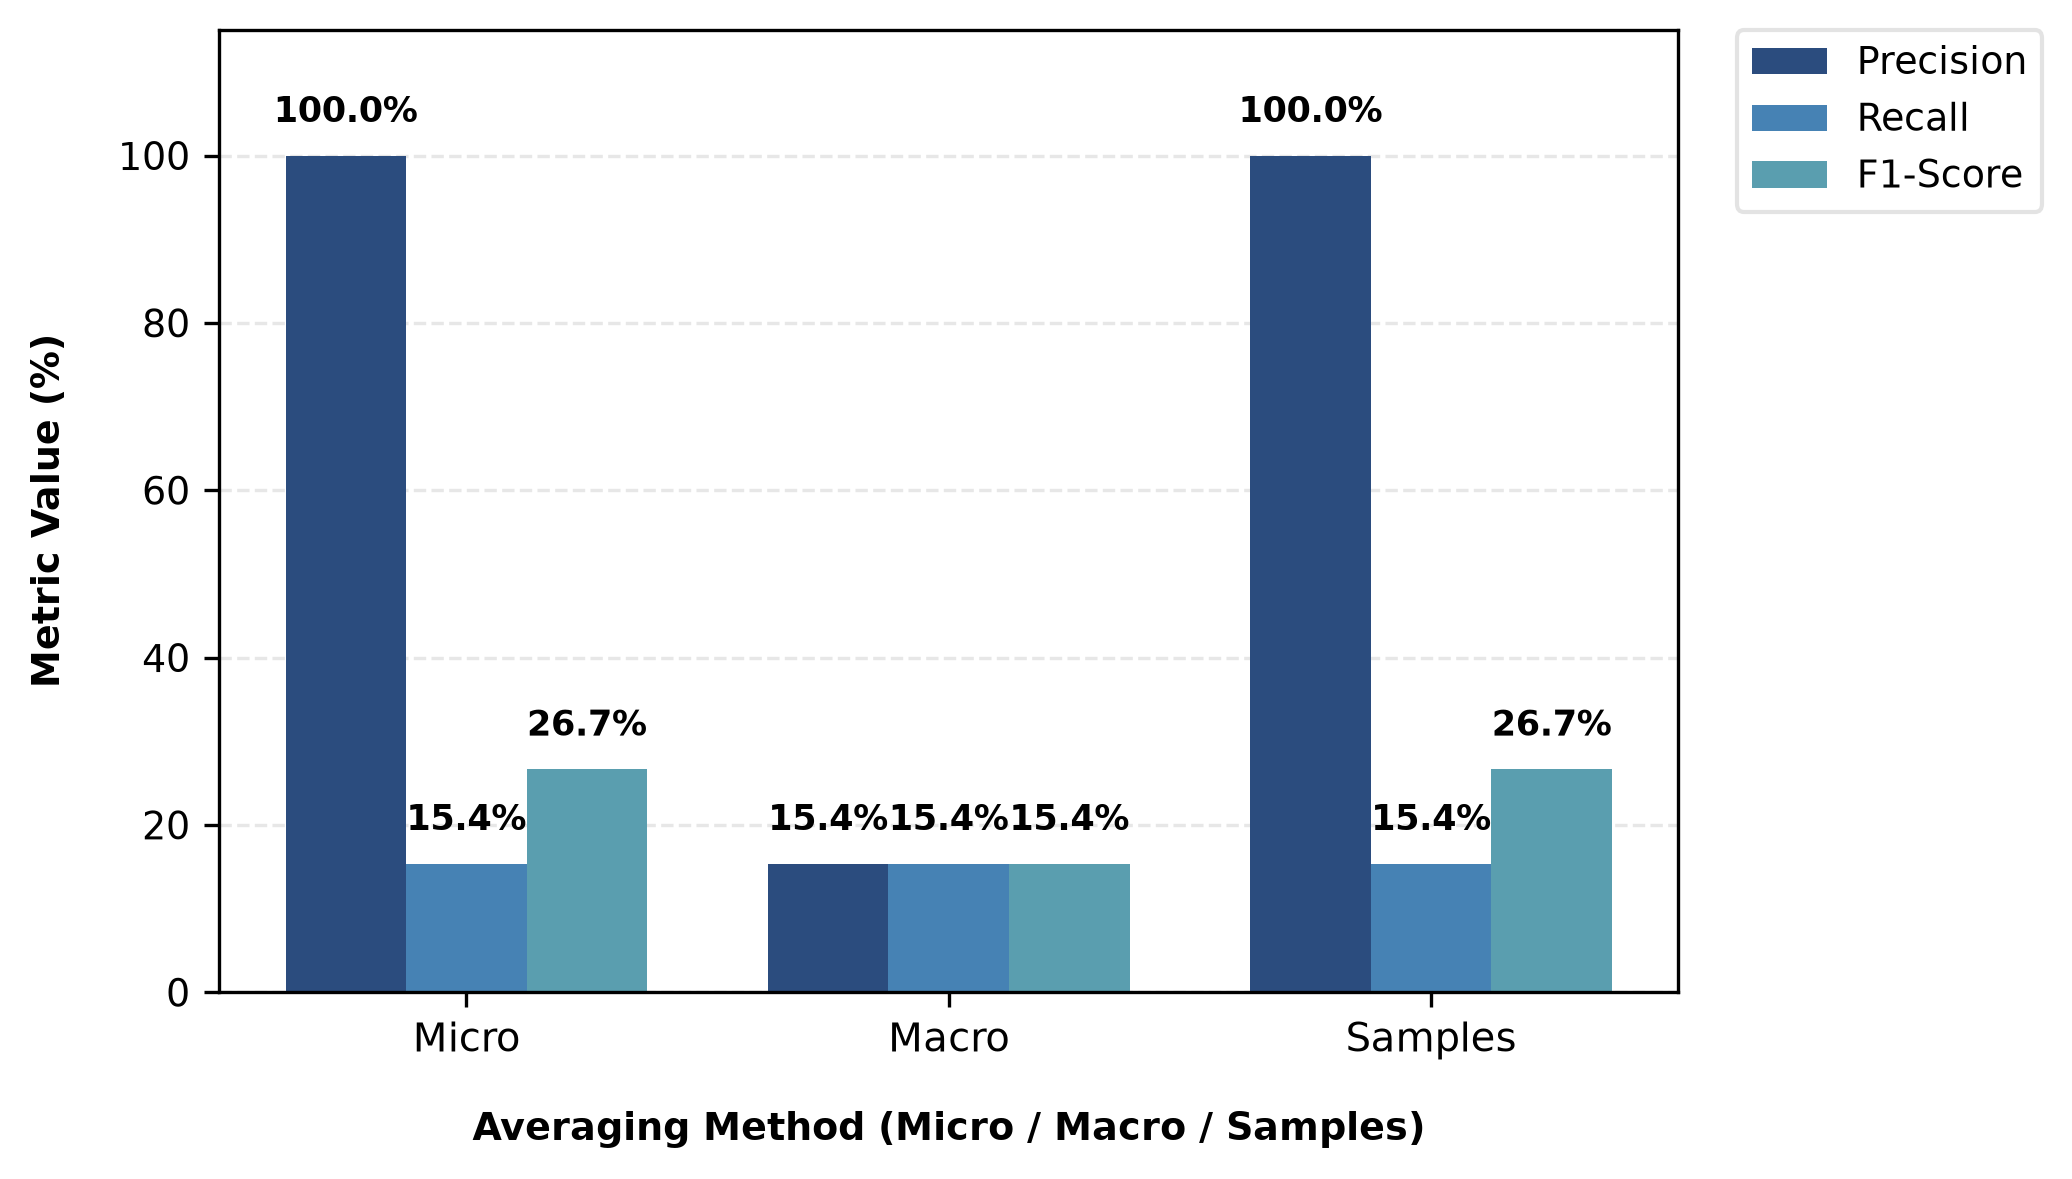

In [7]:
plot_micro_macro_samples(rows, "apk_set1", "../figures/figures_waze_10_runs")

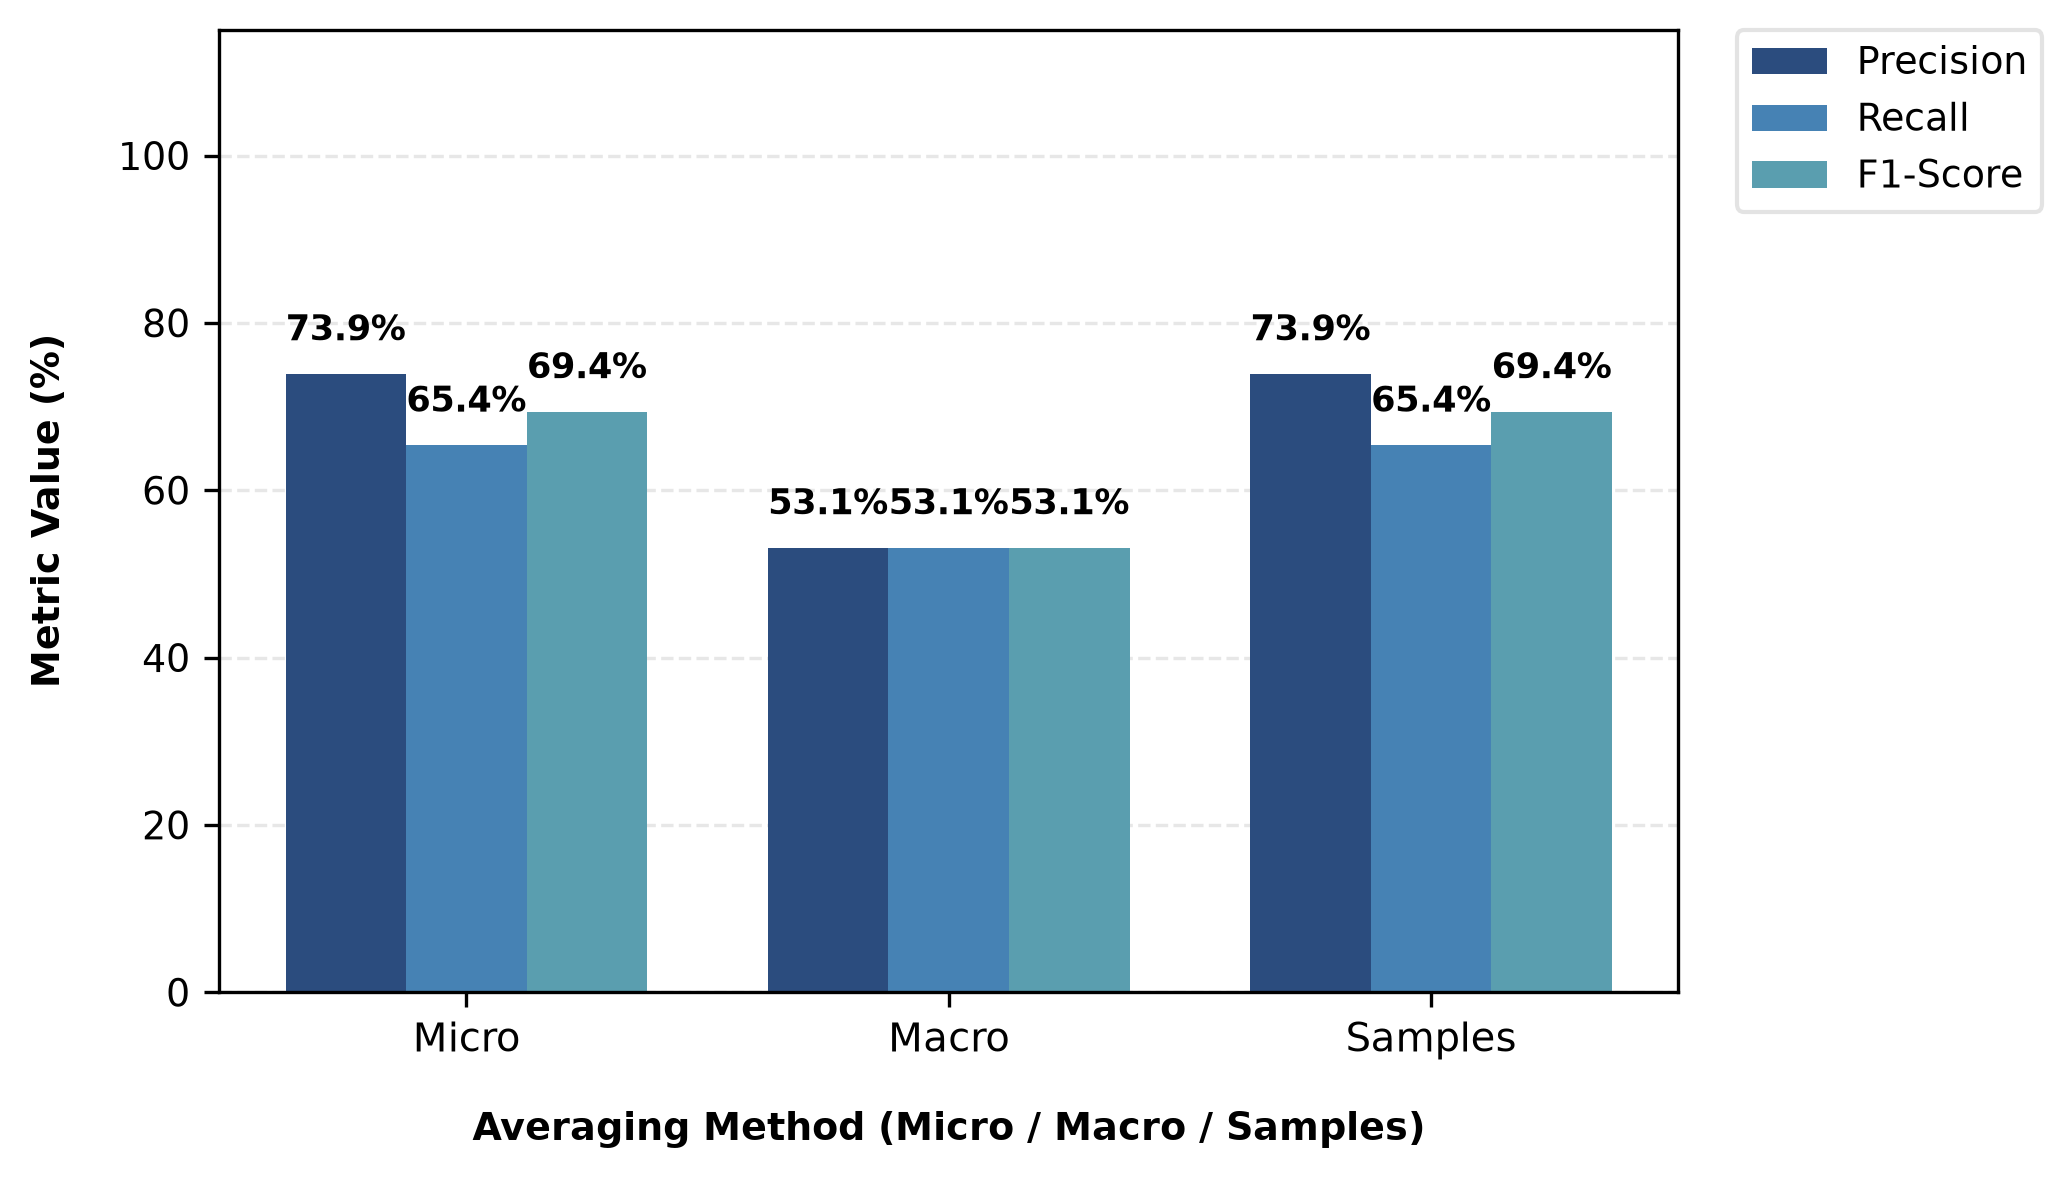

In [8]:
plot_micro_macro_samples(rows, "apk_set2", "../figures/figures_waze_10_runs")

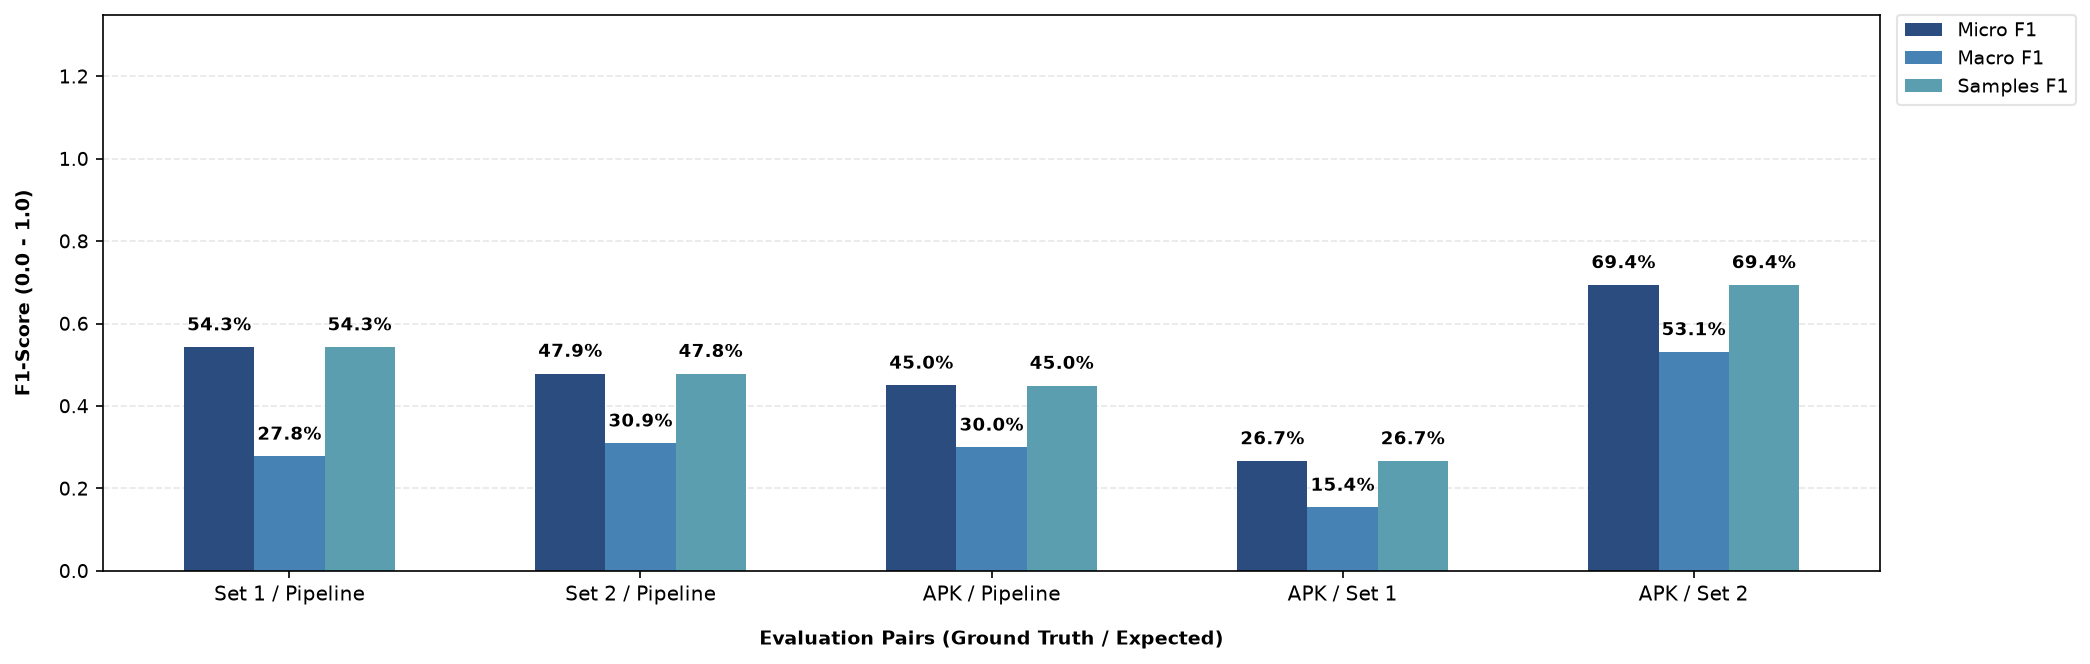

In [9]:
plot_all_micro_macro_samples(rows,"../figures/figures_waze_10_runs")

In [10]:
# Calculate samples with standard deviation for apk_permissions vs inferred_permissions
comps = build_pairs(runs, "apk_permissions", "inferred_permissions")
result = calculate_samples_with_std(
    runs=comps, 
    key_true="apk_permissions", 
    key_pred="inferred_permissions"
)

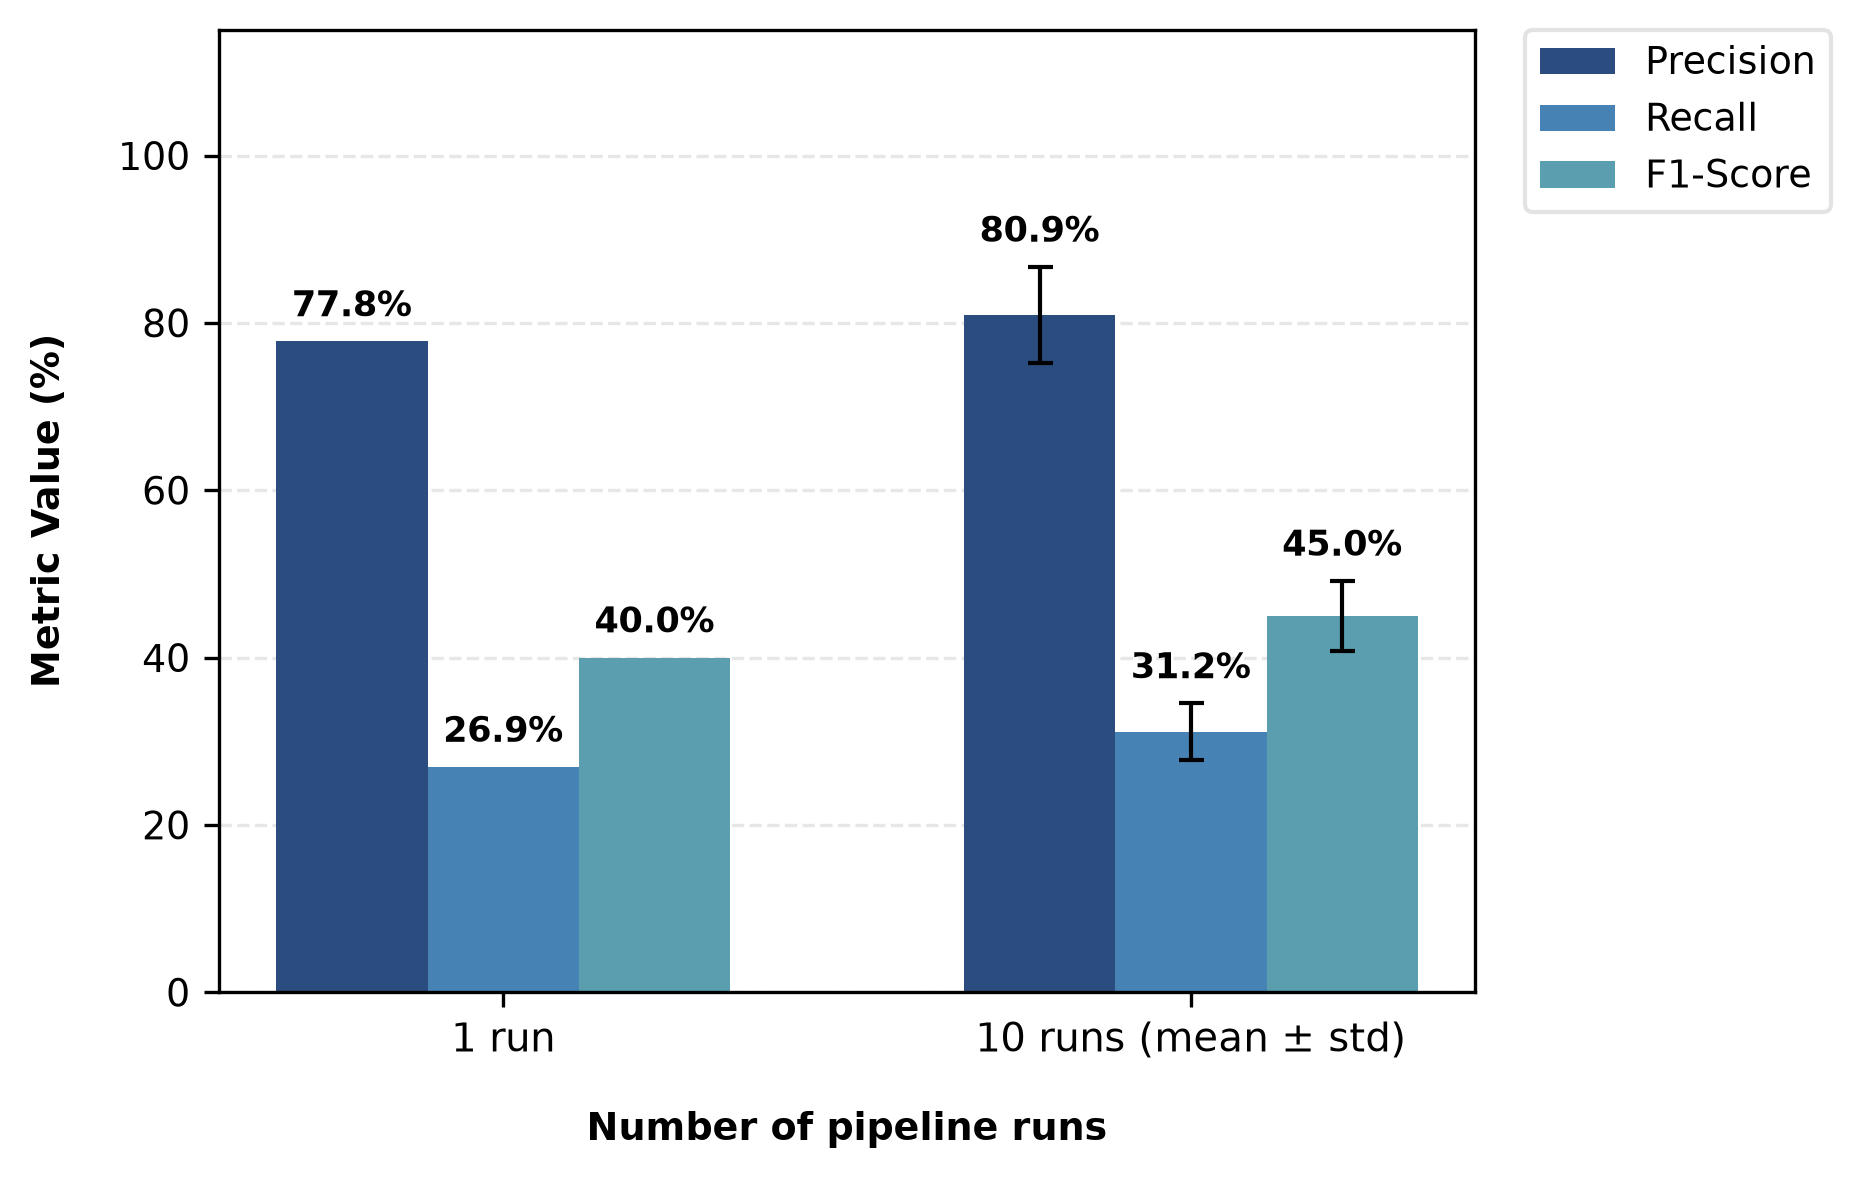

In [11]:
# Create data list with metrics from single run and mean of 10 runs, including standard deviations
data_list = [
    {
        "compare": "1_run",
        "label_gt_pred": "1 run",       
        "precision_samples": 0.7778,  
        "recall_samples": 0.2692,
        "f1_samples": 0.4000
    },
    {
        "compare": "10_runs",
        "label_gt_pred": "10 runs (mean ± std)",
        "precision_samples": result["precision_samples"],
        "precision_std": result["precision_std"],
        "recall_samples": result["recall_samples"],
        "recall_std": result["recall_std"],
        "f1_samples": result["f1_samples"],
        "f1_std": result["f1_std"]
    }
]
plot_runs_with_std(data_list, ["1_run", "10_runs"], "../figures/figures_waze_10_runs")